In [143]:
import sys
sys.path.insert(0, '..')

In [144]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)

# Optimisation imports
import zodiax as zdx
import optax

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from fisher import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *


def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

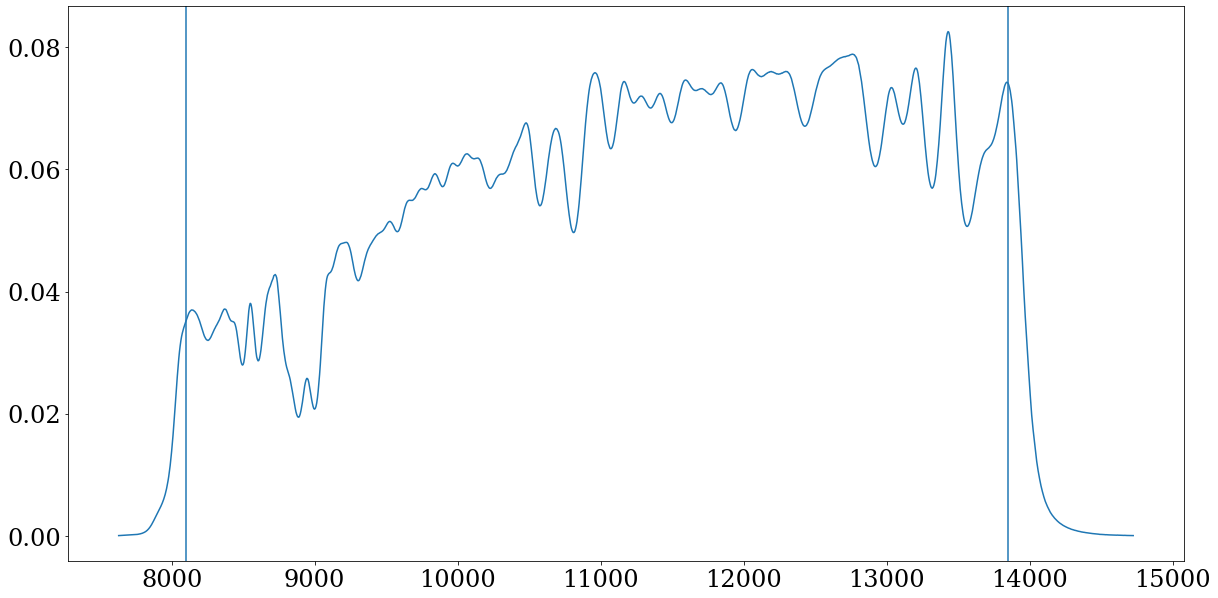

In [145]:
plt.figure(figsize=(20,10))
flt = get_filter("../data/HST_NICMOS1.F110W.dat")
plt.plot(flt[:,0], flt[:,1])
plt.axvline(8100)
plt.axvline(13850)

In [146]:
wid = 72
oversample = 4

filt = "F110W"

nwavels = 1420//4
npoly=nwavels
n_zernikes = 20

optics = NICMOSFresnelOptics(512, wid, oversample, n_zernikes = n_zernikes, defocus=0., fnumber=80.)
detector = NICMOSDetector(oversample, wid)

In [147]:
nwavels

355

In [148]:
wavels, bandpass = calc_throughput("F110W", nwavels=nwavels)

In [149]:
wavels, weights = calc_throughput(filt, nwavels)


In [150]:
data = np.load("spectrum_iterative.npz", allow_pickle=True)
weights = np.ones_like(data["weights"])
# weights = (data["weights"])

params = data["params"][()]

key_name = list(params["aberrations"].keys())[0]

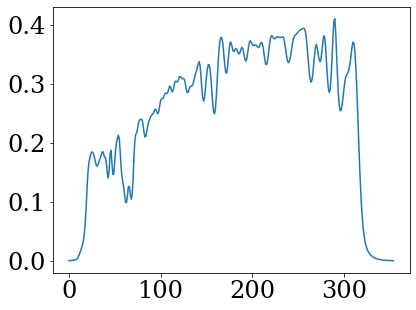

In [151]:
plt.plot(weights*bandpass)

In [152]:
weights.shape

(355,)

In [153]:
basis_weights = weights

In [154]:
spectrum_basis = np.eye(nwavels)#*bandpass
#spectrum_basis = np.load("spectrum_basis.npy")[:,:npoly]

In [155]:
exposures = [
    BlankExposure(key_name, filt, SinglePointFit(spectrum_basis, "F110W", precombined=False, wavels=wavels))
] 


/var/folders/hv/659ls99s2sjd7m3dfr17k8cm0000gn/T/ipykernel_83872/141713101.py:2: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  BlankExposure(key_name, filt, SinglePointFit(spectrum_basis, "F110W", precombined=False, wavels=wavels))


In [156]:
params

{'aberrations': {'n9nk29c8q': Array([-21.94859155,   5.03698532,  -4.95393384,   0.32311236,
          -1.92592954,  -2.60298832,   9.0831775 ,   2.31795581,
          -7.90617164,  -2.9725383 ,   0.96677304,  10.42081623,
          -8.91603272,   0.24865435,   3.09822556,   0.22262045,
           0.21445273,   3.10756596,   4.96647266,   2.0922636 ],      dtype=float64),
  'n9nk29d1q': Array([  9.9801923 ,  -4.43229112, -12.93844726,   2.64381533,
          -1.20478235, -10.23353929,  13.25965472,  -0.4817362 ,
          -1.09728038,  -1.03899602,  -1.48565045,  11.87279729,
          -7.4875088 ,  -0.26511584,   0.54763496,  -4.20229032,
          -2.1372208 ,  -2.29799959,  -6.56908521,  -0.62091824],      dtype=float64)},
 'bias': {'n9nk29c8q': Array(0.03111953, dtype=float64),
  'n9nk29d1q': Array(0.02695366, dtype=float64)},
 'cold_mask_shear': {'global': Array([-0.22296075, -0.34786933], dtype=float64)},
 'cold_mask_shift': {'global': Array([6.61339729, 5.90511779], dtype=float6

In [157]:
base_params = {
    #"fluxes": {},
    "positions": {},
    "spectrum": {},
    "aberrations": {},

    #"rot": 0.,

    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,

    "softening": 20.,#0.1,
    "bias": {},
    "jitter": {},

    "defocus": {},#1e5#{}
    "fnumber": 80.,
    "quadrature": {},
}



for idx, exp in enumerate(exposures):
    base_params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])
    base_params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set(np.log10(np.nansum(exp.data)/nwavels))
    base_params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(n_zernikes)
    base_params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([6.,6.])
    base_params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    base_params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    base_params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    base_params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    base_params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    base_params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    base_params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.
    
    base_params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    base_params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample
    base_params["quadrature"][exp.fit.get_key(exp, "quadrature")] = 0.

params = base_params | params | {"spectrum": {f"{key_name}_F110W": basis_weights}}

injected_model = set_array(NICMOSModel(exposures, params, optics, detector))

injected_params = ModelParams(params)

In [158]:
injected_params

ModelParams(
  params={
    'positions': {'n9nk29c8q': f64[2], 'n9nk29d1q': f64[2]},
    'spectrum': {'n9nk29c8q_F110W': f64[355]},
    'aberrations': {'n9nk29c8q': f64[20], 'n9nk29d1q': f64[20]},
    'cold_mask_shift': {'global': f64[2]},
    'cold_mask_rot': {'global': -45.0},
    'cold_mask_scale': {'global': f64[2]},
    'cold_mask_shear': {'global': f64[2]},
    'primary_scale': {'global': f64[2]},
    'primary_rot': {'global': 45.0},
    'primary_shear': {'global': f64[2]},
    'outer_radius': 1.146,
    'secondary_radius': 0.44639999999999996,
    'spider_width': 0.0924,
    'softening': 20.0,
    'bias': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'jitter': {'n9nk29c8q': 0.6511627906976745},
    'defocus': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'fnumber': 80.0,
    'quadrature': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]}
  }
)

In [159]:
exposures = [
    #InjectedExposure("test", 'F110W', SinglePointSpectrumFit(nwavels), injected_model, 287*1e-3, 10)
    InjectedExposure(key_name, filt, SinglePointFit(spectrum_basis, filt), injected_model, 100, 1, read_noise=0.)
]

/var/folders/hv/659ls99s2sjd7m3dfr17k8cm0000gn/T/ipykernel_83872/3807808512.py:3: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  InjectedExposure(key_name, filt, SinglePointFit(spectrum_basis, filt), injected_model, 100, 1, read_noise=0.)


In [160]:
# exposures = [
#     LoadedExposure(key_name, filt, SinglePointFit(np.eye(nwavels), filt, precombined=True, wavels=wavels), exp.data, exp.err, exp.bad) for exp in exposures
# ]

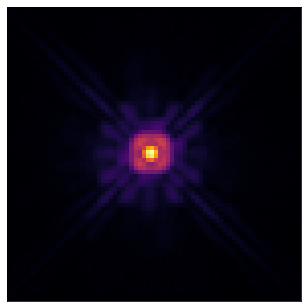

In [161]:
plt.imshow(exposures[0].data**0.125)
plt.xticks([])
plt.yticks([])
plt.tight_layout()

In [162]:
print(np.sum(exposures[0].data))

501.49168684099766


In [163]:
11811045.472931193/18717.32145868043

631.0222057683178

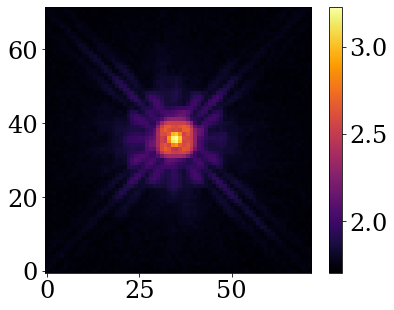

In [164]:
plt.imshow(np.log10(exposures[0].data/exposures[0].err))
plt.colorbar()

In [165]:


model = set_array(NICMOSModel(exposures, injected_params.params, optics, detector))

old_params = params
params = injected_params#ModelParams(injected_params)

In [166]:
old_params

{'positions': {'n9nk29c8q': Array([ 0.95752274, -0.03478353], dtype=float64),
  'n9nk29d1q': Array([-0.43195931,  0.67144459], dtype=float64)},
 'spectrum': {'n9nk29c8q_F110W': Array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.

In [167]:
model

NICMOSModel(
  params={
    'aberrations': {'n9nk29c8q': f64[20], 'n9nk29d1q': f64[20]},
    'bias': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'cold_mask_rot': {'global': f64[]},
    'cold_mask_scale': {'global': f64[2]},
    'cold_mask_shear': {'global': f64[2]},
    'cold_mask_shift': {'global': f64[2]},
    'defocus': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'fnumber': f64[],
    'jitter': {'n9nk29c8q': f64[]},
    'outer_radius': f64[],
    'positions': {'n9nk29c8q': f64[2], 'n9nk29d1q': f64[2]},
    'primary_rot': {'global': f64[]},
    'primary_scale': {'global': f64[2]},
    'primary_shear': {'global': f64[2]},
    'quadrature': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'secondary_radius': f64[],
    'softening': f64[],
    'spectrum': {'n9nk29c8q_F110W': f64[355]},
    'spider_width': f64[]
  },
  filters={'F110W': f64[284,2]},
  optics=NICMOSFresnelOptics(
    wf_npixels=512,
    diameter=f64[],
    layers={
      'CompoundAperture':
      CompoundAperture(
      

In [168]:
model_forecast = injected_params.inject(model)

In [169]:
def loss_fn(params, exposures, model):
    mdl = params.inject(model)
    return np.nansum(np.asarray([posterior(mdl,exposure) for exposure in exposures]))

spec_params = ModelParams({"spectrum": injected_params.get("spectrum")})

f = lambda params: loss_fn(ModelParams(injected_params.params | params.params), exposures, params.inject((model)))
F, unflatten = zdx.batching.hessian(f, spec_params, nbatches=20*len(exposures))

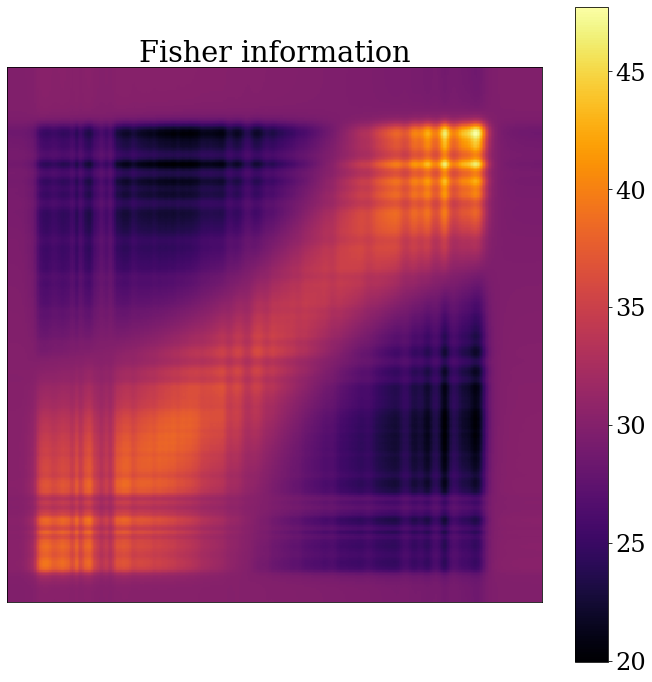

In [170]:
plt.figure(figsize=(10,10))
plt.imshow(F, interpolation='none')
plt.title("Fisher information")
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.tight_layout()

In [171]:
np.sum(np.abs(F - F.T)**2)

Array(1.78359406e-22, dtype=float64)

In [172]:
np.min(F)

Array(19.95059178, dtype=float64)

In [173]:
np.linalg.inv(F)

Array([[ 3.81854394e+13, -4.27313989e+13,  1.21417510e+12, ...,
         4.96931549e+13, -2.54710615e+13, -5.36408388e+12],
       [-2.20699867e+13,  4.11409944e+13, -4.13134948e+13, ...,
        -7.24205899e+13, -7.24568978e+12,  2.79029051e+13],
       [-5.61703607e+12, -1.44991756e+13,  5.21121550e+13, ...,
         4.99388398e+13,  4.35518020e+13, -5.64269132e+13],
       ...,
       [-1.65557108e+13,  7.98274378e+12,  2.30569306e+13, ...,
        -5.03241464e+12,  1.00397156e+13,  4.08497766e+12],
       [ 1.60956067e+13, -3.19848132e+13,  2.06388243e+13, ...,
         4.43639379e+13,  1.28457095e+13, -3.43254210e+13],
       [-4.82058328e+12,  1.42050511e+13, -2.50934082e+13, ...,
        -6.15726687e+13, -1.65594438e+13,  3.82008991e+13]],      dtype=float64)

In [174]:
np.real(np.linalg.eig(F)[0].sort()[::-1])

Array([ 1.05772888e+04,  1.33629665e+03,  4.55184919e+02,  1.34111897e+02,
        7.23242454e+01,  3.60884756e+01,  1.46524517e+01,  8.23285835e+00,
        5.50113870e+00,  2.60094646e+00,  1.65971410e+00,  1.09362189e+00,
        5.12995039e-01,  2.96433224e-01,  2.64314417e-01,  1.43661667e-01,
        6.87485042e-02,  4.84098810e-02,  3.24536582e-02,  1.58433595e-02,
        1.04410426e-02,  5.91423231e-03,  3.13623841e-03,  1.60682827e-03,
        8.50550883e-04,  4.17409502e-04,  1.49336901e-04,  8.35136791e-05,
        2.57632814e-05,  1.37321784e-05,  2.23059771e-06,  1.35013532e-06,
        1.80625096e-07,  8.41534504e-08,  1.47367522e-08,  3.18997887e-09,
        6.75170262e-10,  7.02487067e-11,  1.41534941e-11,  1.18849918e-12,
        5.07725967e-13,  4.69159164e-13,  4.57875786e-13,  4.57875786e-13,
        4.34399685e-13,  4.34399685e-13,  4.33636956e-13,  4.33636956e-13,
        4.12622711e-13,  4.12622711e-13,  3.88484090e-13,  3.88484090e-13,
        3.85351291e-13,  

Text(0, 0.5, 'Eigenvalue')

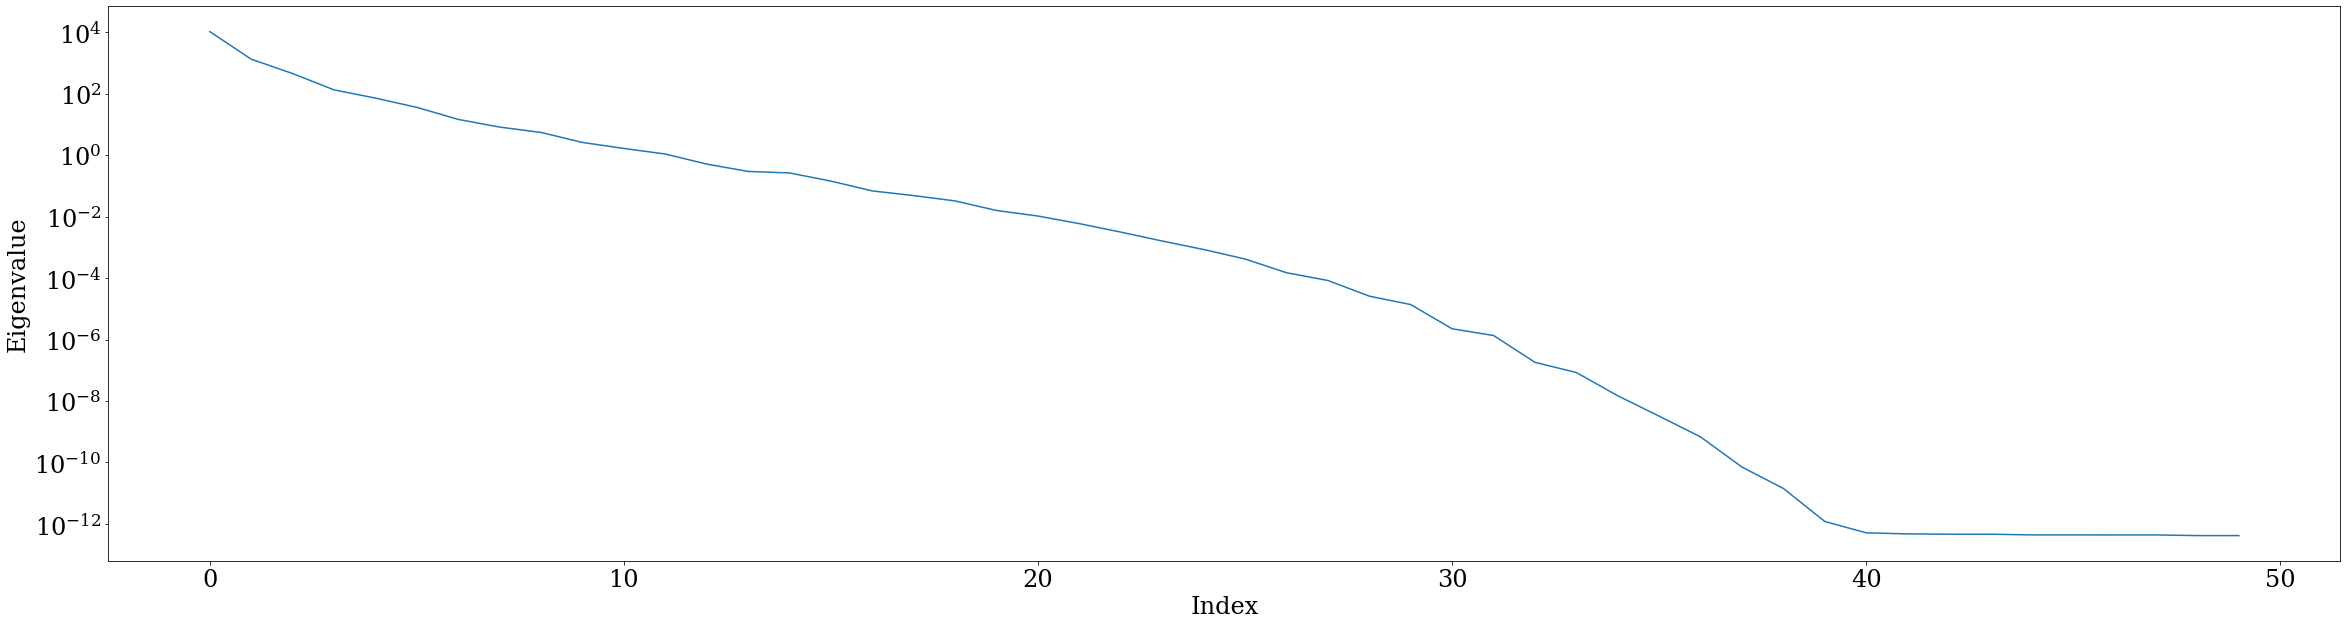

In [175]:
plt.figure(figsize=(40,10))
plt.semilogy(np.real(np.linalg.eig(F)[0].sort()[::-1])[:50])
plt.xlabel("Index")
plt.ylabel("Eigenvalue")

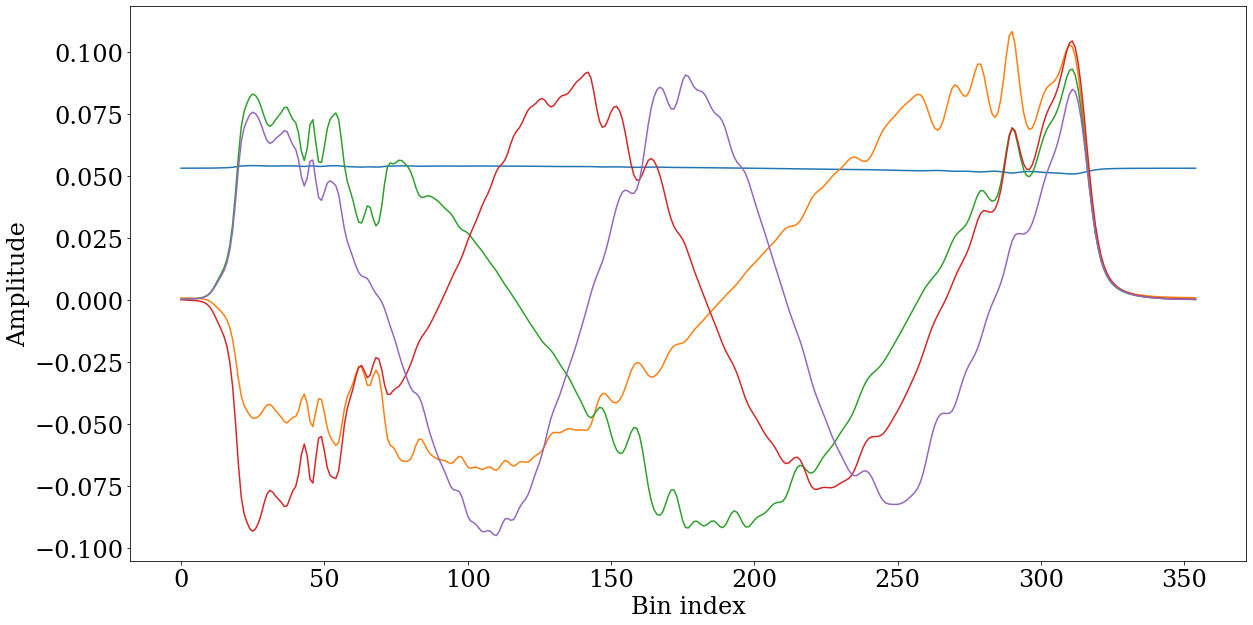

In [176]:
vals, vects = np.linalg.eig(F)

order = np.argsort(vals)[::-1]

plt.figure(figsize=(20,10))
plt.xlabel("Bin index")
plt.ylabel("Amplitude")

for i in range(5):
    plt.plot(np.real(vects[:,order[i]]))

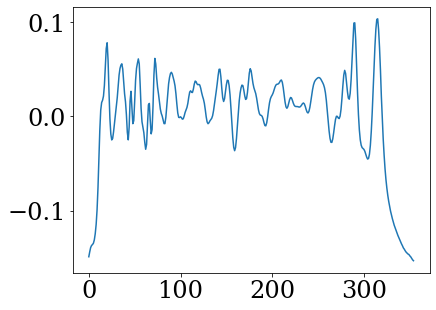

In [177]:
plt.plot(np.real(vects[:,order[-1]]))

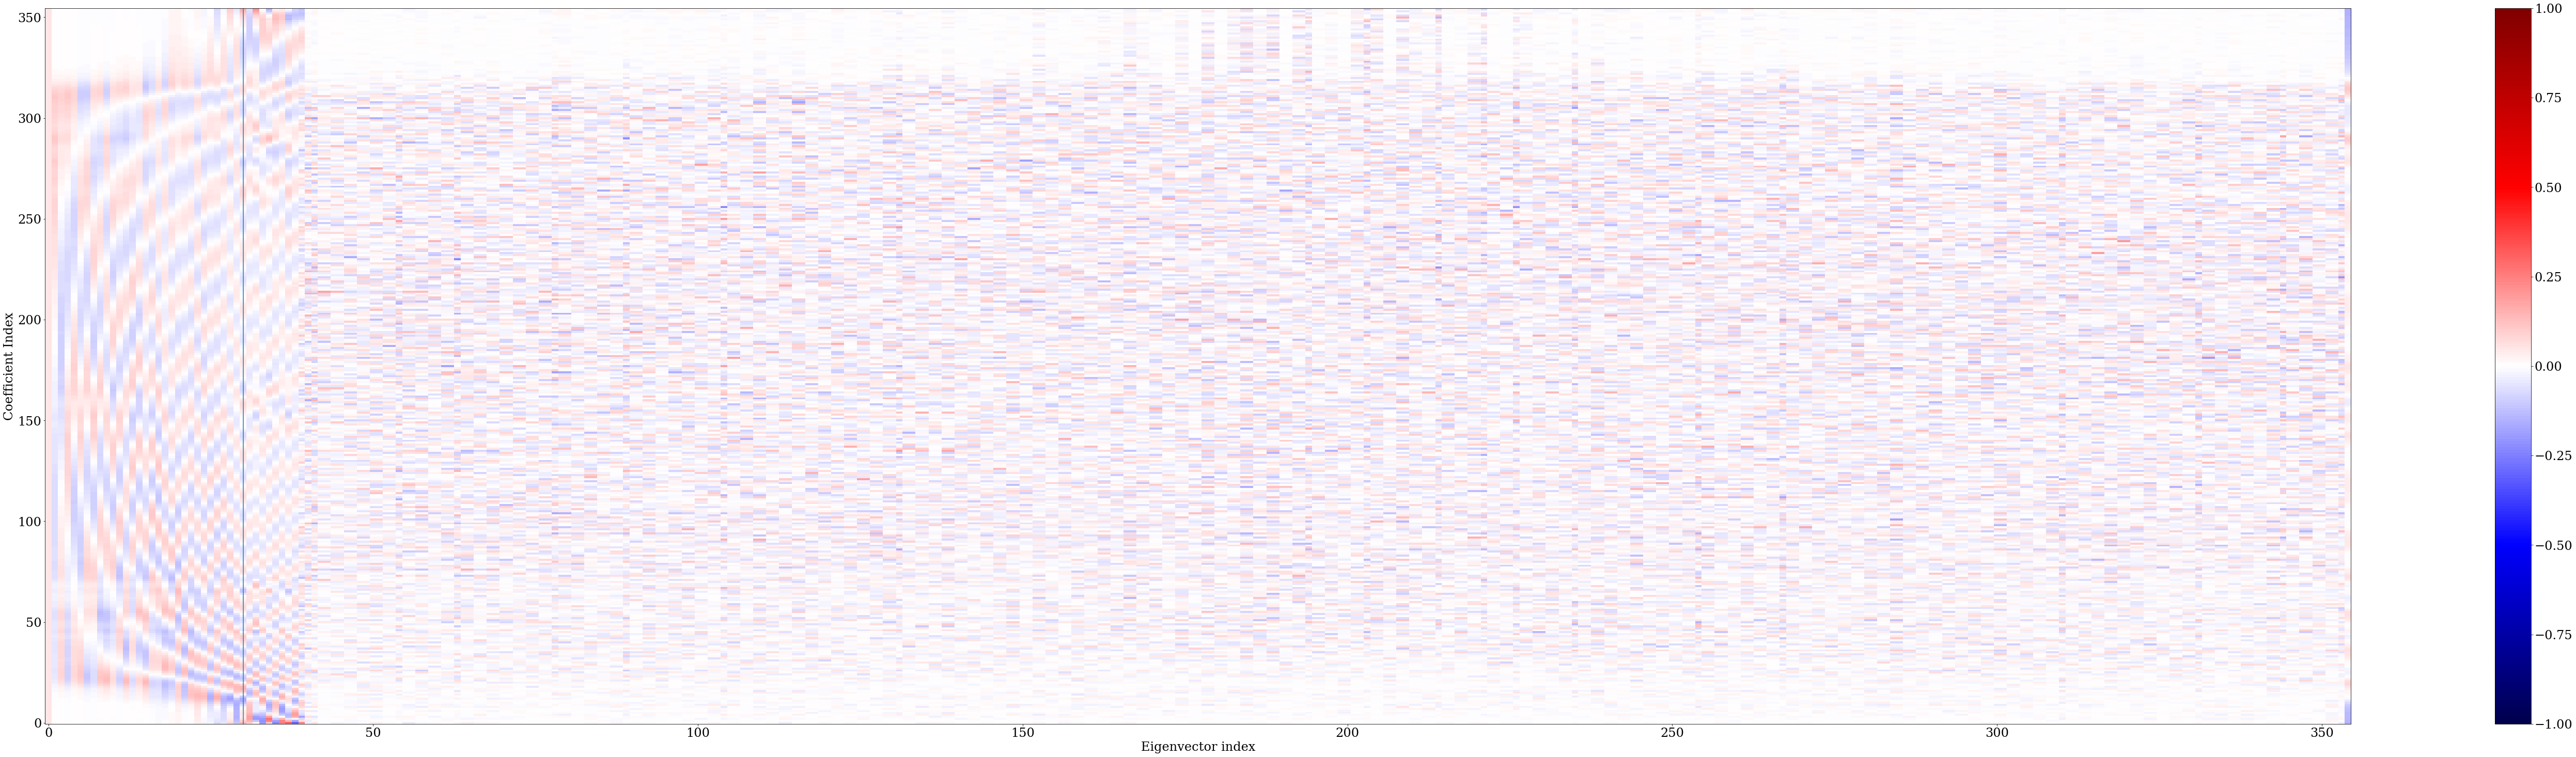

In [178]:
plt.figure(figsize=(20*5,5*5))
plt.imshow(np.real(vects[:,order[:]]), cmap='seismic', vmax=1, vmin=-1, interpolation='none', aspect='auto')
plt.xlabel("Eigenvector index")
plt.ylabel("Coefficient Index")
plt.colorbar()
plt.axvline(30)

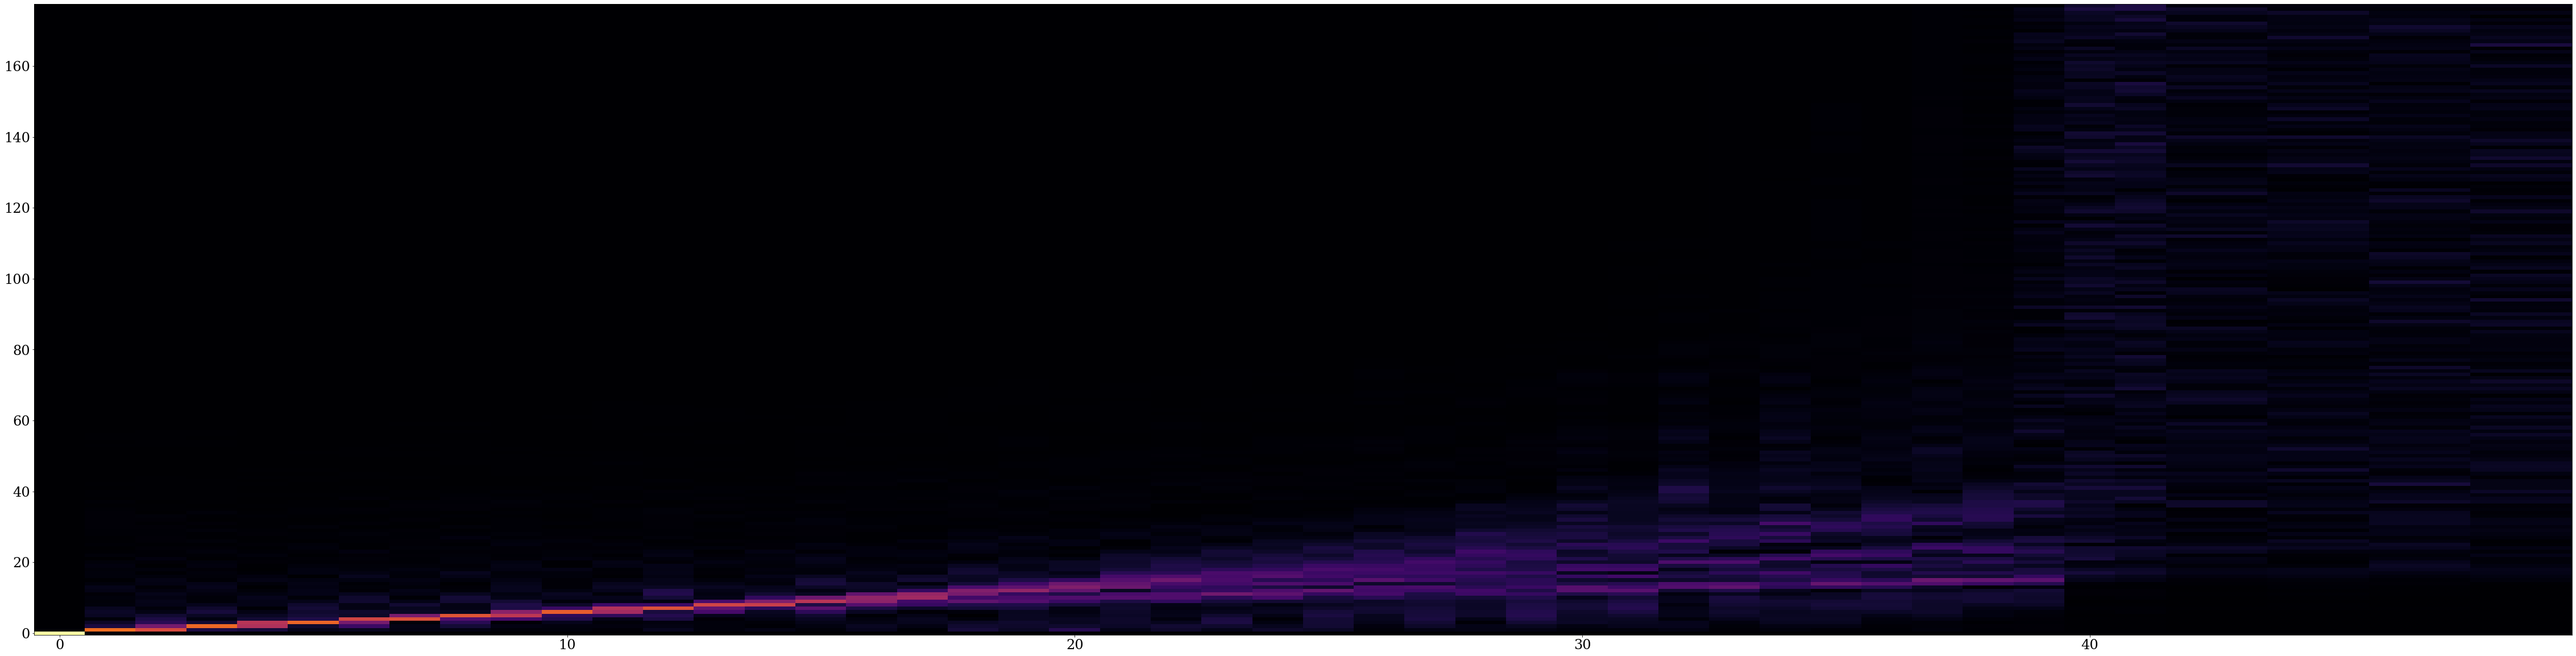

In [179]:
plt.figure(figsize=(20*4, 5*4))
modal_spectrum = np.abs(np.fft.rfft(np.real(vects[:,order[:50]]), axis=0))
plt.imshow(modal_spectrum, aspect='auto')

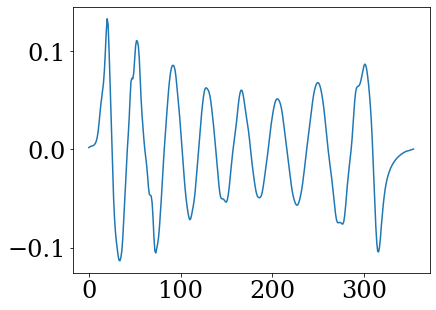

In [180]:
plt.plot(np.real(vects[:,order[15]]))

In [181]:
vcts = np.real(vects[:,order])
vects_adj = vcts#*np.ones(nwavels).at[0].mul(-1)
numpy.save(f"../data/iterative_spectrum_basis.npy", np.real(vects_adj))

In [182]:
wavels, bandpass = calc_throughput("F110W", nwavels=nwavels)

In [183]:
bandpass.shape

(355,)

In [184]:
wv, filt = calc_throughput(filt, nwavels=nwavels)


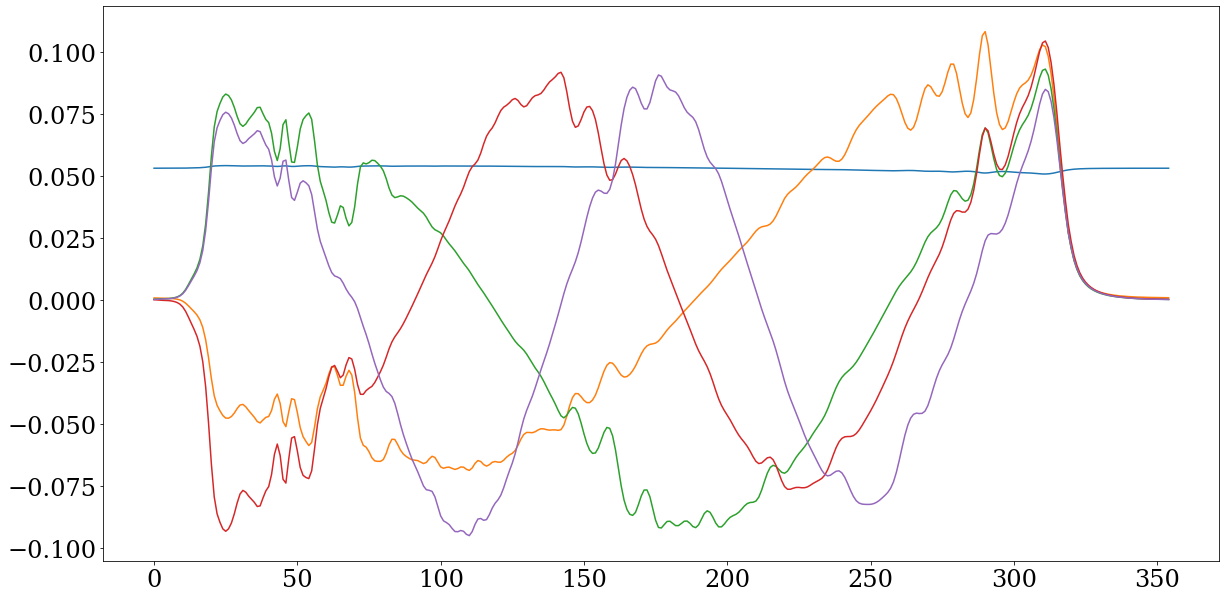

In [185]:
plt.figure(figsize=(20,10))



for i in range(5):
    plt.plot(np.real(vects_adj[:,i]*1))

In [186]:
nvects = 50#npoly
nwavels_binned = 50
upsample = 2

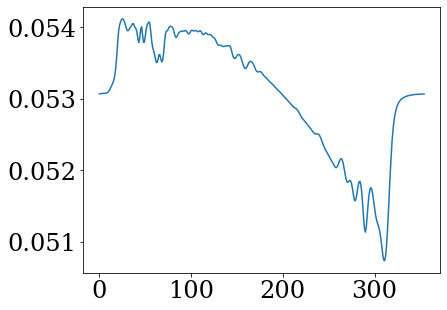

In [187]:
plt.plot(vects_adj[:,0])

In [188]:
bandpass/np.max(bandpass)

Array([5.20957118e-04, 9.09437626e-04, 1.29741686e-03, 1.55928882e-03,
       1.76891083e-03, 2.05054106e-03, 2.61333354e-03, 3.63642195e-03,
       5.32682203e-03, 8.24859521e-03, 1.32689389e-02, 2.11425021e-02,
       3.16734672e-02, 4.31431997e-02, 5.44437258e-02, 6.73051603e-02,
       8.55103708e-02, 1.14445812e-01, 1.60974575e-01, 2.28826598e-01,
       3.07829167e-01, 3.72071665e-01, 4.06842043e-01, 4.25991769e-01,
       4.41771040e-01, 4.49901323e-01, 4.48642528e-01, 4.40949722e-01,
       4.26681635e-01, 4.08602462e-01, 3.94360490e-01, 3.90776029e-01,
       3.98420285e-01, 4.10806140e-01, 4.21841008e-01, 4.33273741e-01,
       4.47191988e-01, 4.51312602e-01, 4.39612757e-01, 4.29174861e-01,
       4.25070196e-01, 4.03011501e-01, 3.62077904e-01, 3.42815303e-01,
       3.75478051e-01, 4.39574723e-01, 4.56302559e-01, 4.03349598e-01,
       3.56457148e-01, 3.59198207e-01, 4.04191073e-01, 4.57086370e-01,
       4.88222159e-01, 5.04542316e-01, 5.18694198e-01, 5.07390465e-01,
      

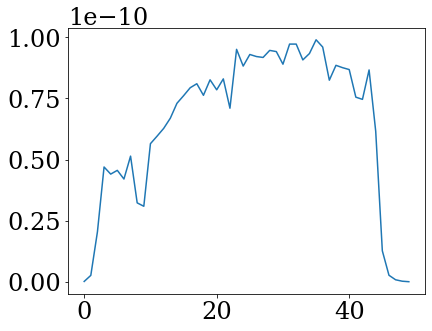

In [189]:
plt.plot(filter_integrate(wavels, vects_adj[:,0]*bandpass/np.max(bandpass), nwavels_binned, norm=False)[1])

In [190]:
filter_integrate(wavels, vects_adj[:,0], nwavels_binned, norm=False)

(Array([7.71074310e-07, 7.85224338e-07, 7.99374366e-07, 8.13524394e-07,
        8.27674423e-07, 8.41824451e-07, 8.55974479e-07, 8.70124507e-07,
        8.84274535e-07, 8.98424563e-07, 9.12574592e-07, 9.26724620e-07,
        9.40874648e-07, 9.55024676e-07, 9.69174704e-07, 9.83324732e-07,
        9.97474761e-07, 1.01162479e-06, 1.02577482e-06, 1.03992485e-06,
        1.05407487e-06, 1.06822490e-06, 1.08237493e-06, 1.09652496e-06,
        1.11067499e-06, 1.12482501e-06, 1.13897504e-06, 1.15312507e-06,
        1.16727510e-06, 1.18142513e-06, 1.19557515e-06, 1.20972518e-06,
        1.22387521e-06, 1.23802524e-06, 1.25217527e-06, 1.26632530e-06,
        1.28047532e-06, 1.29462535e-06, 1.30877538e-06, 1.32292541e-06,
        1.33707544e-06, 1.35122546e-06, 1.36537549e-06, 1.37952552e-06,
        1.39367555e-06, 1.40782558e-06, 1.42197561e-06, 1.43612563e-06,
        1.45027566e-06, 1.46442569e-06], dtype=float64),
 Array([1.06071035e-10, 1.06187161e-10, 1.06980907e-10, 1.08088029e-10,
       

In [191]:
vects_binned = np.zeros((nwavels_binned,nvects))
vects_binned_upsampled = np.zeros((nwavels_binned*upsample,nvects))
vects_filt_binned = np.zeros((nwavels_binned,nvects))


for i in range(nvects):
    wavels_binned, vect_binned = filter_integrate(wavels, vects_adj[:,i], nwavels_binned, norm=False)
    wavels_binned_upsampled, vect_binned_upsampled = filter_integrate(wavels, vects_adj[:,i], nwavels_binned*upsample, norm=False)
    _, vect_filt_binned = filter_integrate(wavels, vects_adj[:,i]*bandpass, nwavels_binned, norm=False)
    #_, vect_filt_binned = filter_integrate(wavels, vects_adj[:,i], nwavels_binned, norm=False)
    vects_binned = vects_binned.at[:,i].set(vect_binned)
    vects_filt_binned = vects_filt_binned.at[:,i].set(vect_filt_binned)
    vects_binned_upsampled = vects_binned_upsampled.at[:,i].set(vect_binned_upsampled)

In [192]:
vects_binned = vects_binned/np.sqrt(np.mean(vects_binned[:,:]**2, axis=0))
vects_filt_binned = vects_filt_binned/np.sqrt(np.mean(vects_filt_binned[:,:]**2, axis=0))
vects_binned_upsampled = vects_binned_upsampled/np.sqrt(np.mean(vects_binned_upsampled[:,:]**2, axis=0))

In [193]:
nvects

50

In [194]:
np.sqrt(np.mean(vects_binned[:,:]**2, axis=0))

Array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],      dtype=float64)

In [195]:
nv = 30
msk = np.arange(nv)#np.concat((np.arange(nv-1), np.array([-1])))

In [196]:
vects_binned = vects_binned[:,msk]
vects_filt_binned = vects_filt_binned[:,msk]
vects_binned_upsampled = vects_binned_upsampled[:,msk]

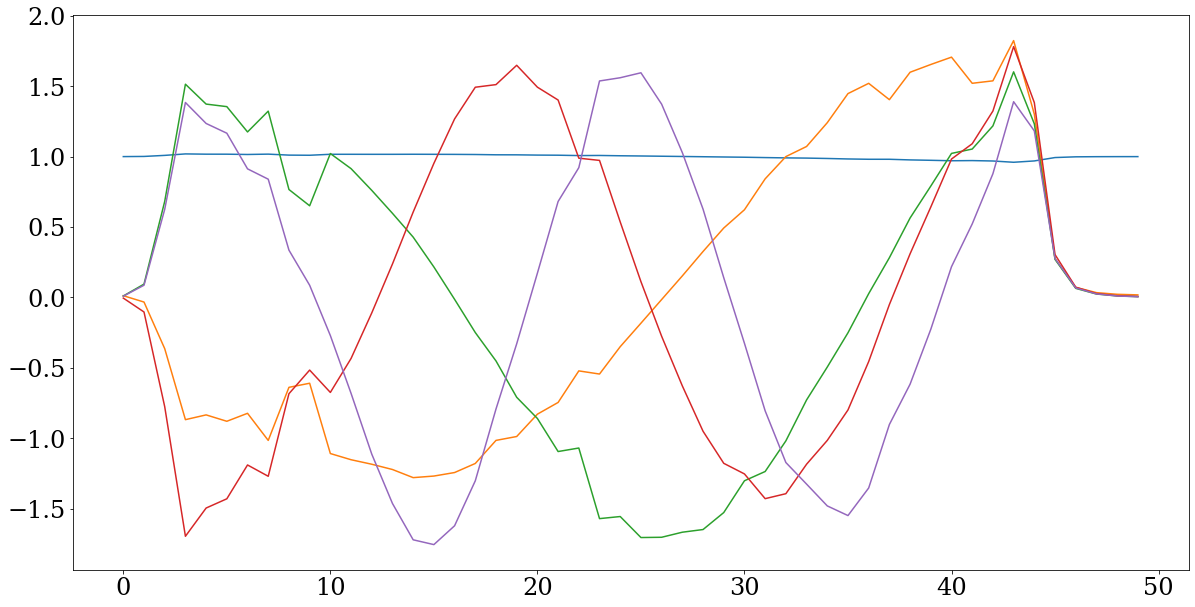

In [197]:
plt.figure(figsize=(20,10))



for i in range(5):
    plt.plot(np.real(vects_binned[:,i]))

Text(0, 0.5, 'Photon throughput')

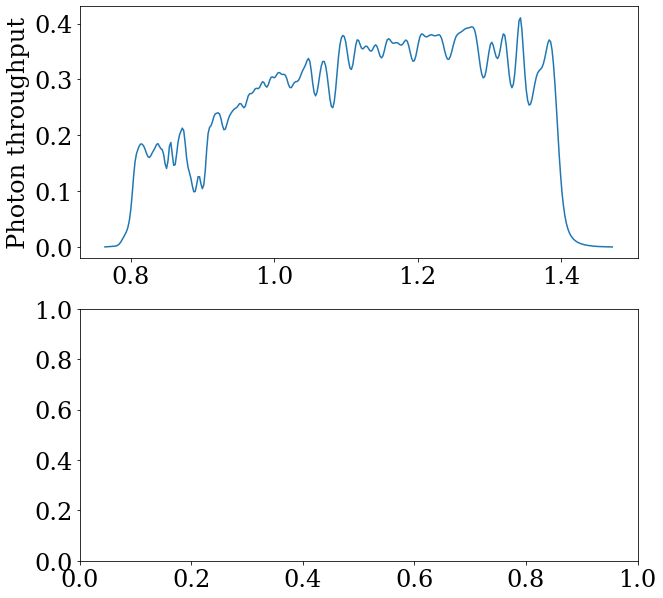

In [ ]:
fig, axs = plt.subplots(2,1, figsize=(10,10))
axs[0].plot(wavels/1e-6, bandpass)
axs[0].set_ylabel("Photon throughput")
axs[0].set_xlabel("Wavelength (µm)")

In [198]:
#stop

In [199]:
numpy.savez(f"../data/iterative_basis_binned.npz", 
    wavels_binned=wavels_binned,
    wavels_binned_upsampled=wavels_binned_upsampled,
    vects_binned=vects_binned,
    vects_filt_binned=vects_filt_binned,
    vects_binned_upsampled=vects_binned_upsampled,
    big_basis=vects_adj[:,:nvects]
)